# Introduction to MLOps

**Applied ML in Production · Session 8**

---

Every session so far ended with a model that scored well on data we already had.
This one is about the part nobody warns you about: a model in production is not
a result, it is a **process that runs forever in a world that keeps changing**.

We will look at what has to exist around a model for it to be owned rather than
merely built — deployment workflow, monitoring, retraining, CI/CD — and then we
will watch this dataset break.

Because it does break. There has been a shift hiding in the loan book since
session 2, and every notebook so far has quietly stepped over it. Today we find
it, measure it, and decide what to do about it.

## How to work through this

Type the code. The monitoring section is deliberately plain — grouping by month
and comparing distributions — because that is genuinely what production
monitoring looks like underneath the dashboards.

Run each cell, read the output, then read the commentary. If a cell errors, run
from the top.

## Learning objectives

After this session you will be able to:

- Say what a deployed model consists of, beyond the model file.
- Describe shadow, canary and champion–challenger deployments, and when each is used.
- Monitor three layers — system, data, and model — and explain what to do when
  labels arrive months late.
- Distinguish **data drift** from **concept drift**, and detect the first without
  any labels at all.
- Compute and read a **population stability index**.
- Choose between recalibrating a threshold and retraining a model.
- Read a Dockerfile and a CI workflow for an ML project and say what each step protects.

## Setup

We train on everything up to 30 June 2024 and treat July onward as "production" —
applications arriving one month at a time, scored by a model that was trained
before they existed.

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.width", 130)


def find_repository_root():
    for folder in [Path.cwd(), *Path.cwd().parents]:
        if (folder / "data").is_dir():
            return folder
    raise FileNotFoundError("could not find the repository root")


ROOT = find_repository_root()
loans = pd.read_csv(ROOT / "data" / "loan_default.csv", parse_dates=["application_date"])

NUMERIC = ["loan_amount", "tenure_months", "interest_rate", "previous_loans",
           "days_past_due_history", "annual_income", "credit_score"]
CATEGORICAL = ["sector", "employment_type", "has_collateral"]

preprocessing = ColumnTransformer([
    ("numeric", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), NUMERIC),
    ("categorical", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                              ("encode", OneHotEncoder(handle_unknown="ignore", drop="first"))]), CATEGORICAL),
])

GO_LIVE = pd.Timestamp("2024-07-01")
training = loans[loans["application_date"] < GO_LIVE]
production = loans[loans["application_date"] >= GO_LIVE].copy()

model = Pipeline([("prepare", preprocessing), ("classify", LogisticRegression(max_iter=1000))])
model.fit(training[NUMERIC + CATEGORICAL], training["defaulted"])

print(f"trained on {len(training):,} applications up to {GO_LIVE - pd.Timedelta(days=1):%d %b %Y}")
print(f"training default rate: {training['defaulted'].mean():.1%}")
print(f"production stream: {len(production):,} applications from {GO_LIVE:%b %Y} onward")

trained on 9,029 applications up to 30 Jun 2024
training default rate: 11.9%
production stream: 2,971 applications from Jul 2024 onward


---

## 1. What a deployed model actually is

A trained pipeline is one item on a list. To put a model into service you need all
of these, and a team that knows where each one lives:

| Component | What it is | Where it came from |
|-----------|------------|--------------------|
| **Model artifact** | The serialised pipeline | Session 7's MLflow run |
| **Input schema** | Field names, types, allowed ranges | Session 1's specification |
| **Decision rule** | The threshold, and any per-segment variation | Sessions 5 and 6 |
| **Serving code** | The API that loads the artifact and answers | Session 9 |
| **Monitoring** | What is measured, how often, and the alarm levels | This session |
| **Runbook** | What to do when an alarm fires, and who does it | This session |
| **Owner** | A named person accountable for it in six months | Your organisation |

The last two are the ones that get skipped, and they are the reason models rot
quietly instead of failing loudly.

### The production loop

Session 1's CRISP-DM diagram ended with Deployment pointing back to Business
Understanding. In production that arrow is a schedule:

```
   train  →  package  →  deploy  →  serve  →  monitor  →  decide
     ↑                                                      │
     └──────────────  retrain / recalibrate / roll back  ────┘
```

**MLOps is the practice of making every arrow in that loop routine** — automated
where possible, documented where not, and owned in all cases.

---

## 2. Deployment workflow

Nobody sensible replaces a live decision system in one step. The standard ladder:

| Pattern | What happens | What it protects against |
|---------|--------------|--------------------------|
| **Shadow** | The new model scores live traffic; its output is logged but not used | Crashes, latency, nonsense predictions — at zero business risk |
| **Canary** | A small share of decisions (1–5%) use the new model | Real-world damage from a model that looked fine offline |
| **A/B or champion–challenger** | Two models run side by side, measured against each other | Choosing on offline metrics when the business outcome disagrees |
| **Full rollout** | Everything uses the new model | — |
| **Rollback** | Revert to the previous artifact | Everything else |

Two rules that come from experience rather than theory.

**Rollback must be one command, and it must be tested.** A rollback plan that has
never been run is a hope, not a plan.

**Shadow mode is where you discover the boring failures.** A field that is always
null in production, a category the encoder has never seen, a request that takes
four seconds. None of those appear in a notebook.

> **Industry note — the model that never saw a real request.**
> A common sequence: the offline model is excellent, the API is built, and on day
> one every prediction comes back near the same value. The cause is almost always
> a preprocessing mismatch — the service computes a feature differently from the
> training code. Session 7's pipeline is the structural fix, and shadow mode is
> how you catch what is left.

---

## 3. Monitoring: three layers

| Layer | Examples | How fast you learn |
|-------|----------|--------------------|
| **System** | Latency, error rate, uptime, queue depth | Seconds |
| **Data** | Input distributions, missing-value rates, new categories, schema changes | Minutes to days |
| **Model** | Precision, recall, cost, calibration | **As fast as labels arrive** |

That last row is the hard one. Our charter defines default as observed within
**12 months** of disbursement. A model deployed today cannot be scored properly
until next year.

This is normal — fraud labels take weeks, credit labels take months, churn labels
take a quarter — and it is why production monitoring leans so heavily on the first
two layers. You watch the inputs and the predictions, because those are available
immediately, and you treat a change in them as the early warning for a change in
performance you cannot yet measure.

For teaching purposes we have a luxury production never has: the labels are in the
file. So we can watch the early warnings *and* check, immediately, whether they
were right.

In [2]:
production["probability"] = model.predict_proba(production[NUMERIC + CATEGORICAL])[:, 1]
production["month"] = production["application_date"].dt.to_period("M")

THRESHOLD = 0.20        # the operating point chosen in session 5

from sklearn.metrics import average_precision_score, recall_score, roc_auc_score

rows = []
for month, group in production.groupby("month"):
    flagged = (group["probability"] >= THRESHOLD).astype(int)
    rows.append({
        "month": str(month),
        "applications": len(group),
        "predicted_rate": group["probability"].mean(),
        "actual_rate": group["defaulted"].mean(),
        "flagged": flagged.mean(),
        "recall": recall_score(group["defaulted"], flagged),
        "AP": average_precision_score(group["defaulted"], group["probability"]),
        "AUC": roc_auc_score(group["defaulted"], group["probability"]),
    })

monthly = pd.DataFrame(rows).set_index("month").round(3)
print(monthly.to_string())

         applications  predicted_rate  actual_rate  flagged  recall     AP    AUC
month                                                                            
2024-07           521           0.114        0.113    0.161   0.508  0.381  0.784
2024-08           499           0.126        0.134    0.190   0.552  0.408  0.782
2024-09           488           0.127        0.084    0.201   0.561  0.289  0.804
2024-10           471           0.136        0.242    0.208   0.474  0.555  0.785
2024-11           469           0.135        0.247    0.207   0.397  0.443  0.716
2024-12           523           0.159        0.291    0.264   0.553  0.599  0.763


Stop and read that table before the plot.

For three months the model behaves exactly as designed: the predicted default rate
(0.11–0.13) tracks the actual rate (0.08–0.13), and the review queue holds steady
at 16–20% of applications.

Then October arrives. **The actual default rate doubles to 24%, and keeps
climbing to 29% by December — while the model's predicted rate barely moves,
from 0.13 to 0.16.**

The model is not broken in the sense of being buggy. It is answering a question
about a world that no longer exists.

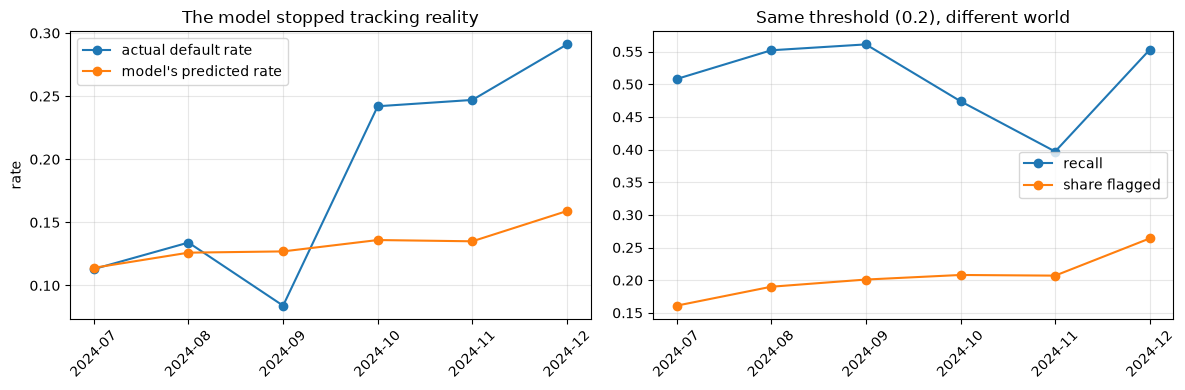

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(monthly.index, monthly["actual_rate"], marker="o", label="actual default rate")
axes[0].plot(monthly.index, monthly["predicted_rate"], marker="o", label="model's predicted rate")
axes[0].set_title("The model stopped tracking reality")
axes[0].set_ylabel("rate")
axes[0].legend()

axes[1].plot(monthly.index, monthly["recall"], marker="o", label="recall")
axes[1].plot(monthly.index, monthly["flagged"], marker="o", label="share flagged")
axes[1].set_title(f"Same threshold ({THRESHOLD}), different world")
axes[1].legend()

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

---

## 4. Two kinds of drift

| | What moved | Example here | Detectable without labels? |
|---|---|---|---|
| **Data drift** (covariate shift) | The distribution of the *inputs* | Interest rates jump, incomes fall | **Yes** — compare distributions |
| **Concept drift** | The *relationship* between inputs and outcome | The same applicant profile now defaults more often | No — needs labels |

Ours is both, which is the usual case. Something changed in the lending
environment in October 2024: rates rose, incomes softened, and borrowers who
would have repaid a year earlier stopped repaying.

The good news is that data drift is visible **immediately**, from the inputs
alone, months before any label arrives.

### The population stability index

PSI compares a feature's distribution now against a reference period. Bucket the
reference into deciles, count what share of the new data falls into each, and sum
the divergence.

| PSI | Conventional reading |
|-----|---------------------|
| below 0.10 | no meaningful change |
| 0.10 – 0.25 | moderate shift — investigate |
| above 0.25 | major shift — act |

In [4]:
def population_stability_index(reference, current, bins=10):
    """How far `current` has moved from `reference`, using the reference's deciles."""
    edges = np.quantile(reference.dropna(), np.linspace(0, 1, bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf

    reference_share = np.histogram(reference.dropna(), bins=edges)[0] / reference.notna().sum()
    current_share = np.histogram(current.dropna(), bins=edges)[0] / current.notna().sum()

    reference_share = np.clip(reference_share, 1e-4, None)
    current_share = np.clip(current_share, 1e-4, None)
    return float(((current_share - reference_share) * np.log(current_share / reference_share)).sum())


watch = ["interest_rate", "annual_income", "loan_amount", "credit_score"]

drift = pd.DataFrame({
    column: {str(month): population_stability_index(training[column], group[column])
             for month, group in production.groupby("month")}
    for column in watch
}).round(3)

drift["predicted_probability"] = [
    round(population_stability_index(
        pd.Series(model.predict_proba(training[NUMERIC + CATEGORICAL])[:, 1]),
        group["probability"]), 3)
    for _, group in production.groupby("month")
]
print(drift.to_string())

         interest_rate  annual_income  loan_amount  credit_score  predicted_probability
2024-07          0.023          0.011        0.031         0.028                  0.017
2024-08          0.020          0.017        0.011         0.049                  0.040
2024-09          0.016          0.034        0.010         0.017                  0.021
2024-10          1.106          0.063        0.019         0.040                  0.042
2024-11          1.450          0.048        0.019         0.007                  0.047
2024-12          1.341          0.104        0.030         0.030                  0.159


There it is, without a single label.

`interest_rate` sits quietly at PSI 0.02 through July, August and September, then
jumps to **1.11 in October** — four times the "major shift" threshold, in the
first month of the change. An alarm on that one number would have fired in early
November, roughly **eleven months before** the defaults it predicts could have
been confirmed.

Three more things in that table are worth arguing about in class.

**`annual_income` drifts too, but mildly** (0.06 to 0.10). The incomes fell by
about 12%; in PSI terms that is a moderate signal you would investigate, not an
emergency. Small PSI does not mean harmless.

**The predicted probability barely drifts** (0.02 to 0.16). The model's *output*
distribution looks almost normal, because it is dutifully mapping the new inputs
through the old relationship. **Prediction drift is a weaker alarm than input
drift.** Monitor both.

**AUC held up** — 0.78, 0.72, 0.76 through the drift window, against 0.78 before.
The model's *ranking* still works: it still sorts risky applicants above safe
ones. What broke is the *level* — how much risk a given profile now implies. That
distinction decides what we do next.

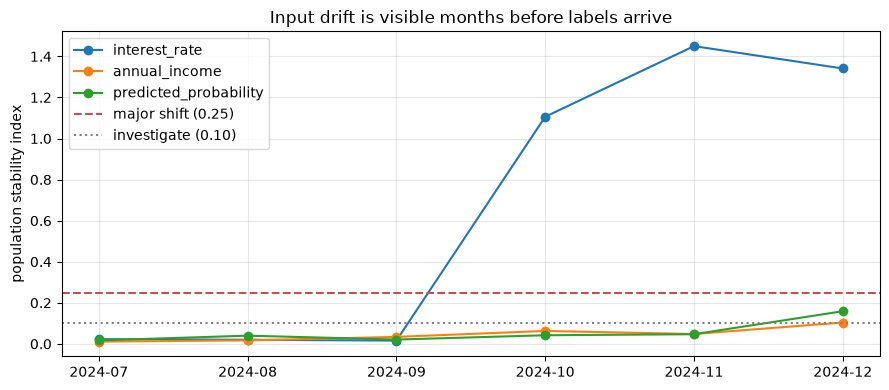

In [5]:
fig, ax = plt.subplots()
drift[["interest_rate", "annual_income", "predicted_probability"]].plot(marker="o", ax=ax)
ax.axhline(0.25, linestyle="--", color="#C44E52", label="major shift (0.25)")
ax.axhline(0.10, linestyle=":", color="grey", label="investigate (0.10)")
ax.set_ylabel("population stability index")
ax.set_title("Input drift is visible months before labels arrive")
ax.legend()
plt.tight_layout()
plt.show()

---

## 5. Responding: recalibrate, retrain, or roll back?

The diagnosis in section 4 — ranking intact, level wrong — points at the cheapest
fix first: **move the threshold**, not the model.

In [6]:
december = production[production["month"] == pd.Period("2024-12")]

print("December 2024, the same model, different thresholds\n")
for threshold in [0.20, 0.15, 0.12, 0.10]:
    flagged = (december["probability"] >= threshold).astype(int)
    missed = december.loc[(december["defaulted"] == 1) & (flagged == 0), "loan_amount"].sum() * 0.55
    false_alarm = december.loc[(december["defaulted"] == 0) & (flagged == 1), "loan_amount"].sum() * 0.045
    print(f"  threshold {threshold:<5} recall {recall_score(december['defaulted'], flagged):.3f}   "
          f"flagged {flagged.mean():.1%}   cost NPR {(missed + false_alarm) / 1e6:.1f}m")

December 2024, the same model, different thresholds

  threshold 0.2   recall 0.553   flagged 26.4%   cost NPR 15.1m
  threshold 0.15  recall 0.664   flagged 36.1%   cost NPR 11.2m
  threshold 0.12  recall 0.724   flagged 46.5%   cost NPR 10.5m
  threshold 0.1   recall 0.796   flagged 55.6%   cost NPR 8.6m


Dropping the threshold from 0.20 to 0.12 lifts December recall from 0.55 to 0.72
and cuts the monthly cost from NPR 15.1m to 10.5m — with the model untouched.

It also pushes the review queue to 47% of applications, far past the charter's
25%. Which is the honest answer: **a worse world costs more to lend in.** The
choice is between more review capacity, more losses, or less lending — and it is
the Head of Credit's choice, not the data scientist's. Your job is to put those
three numbers in front of them quickly.

### Does retraining help?

In [7]:
RETRAIN_CUTOFF = pd.Timestamp("2024-12-01")

retrained = Pipeline([("prepare", preprocessing), ("classify", LogisticRegression(max_iter=1000))])
retrained.fit(loans.loc[loans["application_date"] < RETRAIN_CUTOFF, NUMERIC + CATEGORICAL],
              loans.loc[loans["application_date"] < RETRAIN_CUTOFF, "defaulted"])

old_probabilities = december["probability"]
new_probabilities = retrained.predict_proba(december[NUMERIC + CATEGORICAL])[:, 1]

print(f"December actual default rate: {december['defaulted'].mean():.3f}\n")
print(f"  original model  mean predicted {old_probabilities.mean():.3f}   "
      f"AP {average_precision_score(december['defaulted'], old_probabilities):.3f}")
print(f"  retrained model mean predicted {new_probabilities.mean():.3f}   "
      f"AP {average_precision_score(december['defaulted'], new_probabilities):.3f}")

December actual default rate: 0.291

  original model  mean predicted 0.159   AP 0.599
  retrained model mean predicted 0.198   AP 0.598


Retraining on data that includes two months of the new regime moves the predicted
rate from 0.159 to 0.198 — closer to December's true 0.291, but nowhere near it —
and leaves average precision unchanged at 0.60.

That is a realistic outcome, and it teaches the decision rule:

| Symptom | Likely cause | First response |
|---------|--------------|----------------|
| Ranking holds, level is wrong | Base rate moved | **Recalibrate**: move the threshold, or refit calibration |
| Ranking degrades (AUC falls) | The relationship changed | **Retrain** on recent data |
| Inputs shifted, performance unknown | Data drift, labels pending | Investigate the source; consider shadow-testing a retrained model |
| A feature stopped arriving | Upstream breakage | **Roll back or patch** — this is an engineering incident |
| Sudden, total collapse | Almost always a pipeline bug | Roll back first, diagnose second |

Retraining is not free: it needs enough data from the new regime to learn
anything, and two months of it is thin. Retraining too eagerly on a short window
gives you a model fitted to noise — another reason the threshold is usually the
first lever.

### How often should you retrain?

| Trigger | When it suits |
|---------|---------------|
| **Scheduled** — monthly, quarterly | Stable domains; simple to operate and audit |
| **Triggered by drift** — PSI over a threshold | Domains that move unpredictably, like ours |
| **Triggered by performance** | Only where labels arrive quickly |
| **Never** | More common than anyone admits, and usually an accident |

For this lender, a sensible policy is: PSI monitored weekly on the top five
features, a quarterly scheduled retrain, and an immediate review whenever any
feature crosses 0.25. Write it into the runbook, with a name against it.

---

## 6. CI/CD for machine learning

Continuous integration runs your tests automatically on every change.
Continuous delivery packages and ships the result. For ordinary software that
means "do the unit tests pass". For ML there are three kinds of test, and the
first is the one teams forget.

**1. Data tests.** Does the data still look like the data? This repository already
has them, in `tests/test_spine_data.py` — row counts, column names and order,
missingness within expected bands, the class balance in its teaching range. They
run in half a second and they catch the silent breakages that destroy models.

**2. Pipeline tests.** Does the pipeline fit and predict on a small sample? Does
it produce the expected number of columns? Does it survive an unseen category?

**3. Performance gates.** Does the retrained model still beat the agreed bar on a
held-out set? If cross-validated average precision drops below, say, 0.30, the
pipeline fails and nothing ships.

You do not need to run the two artifacts below — read them. They are what the
deployment of this project would look like, and you will meet both shapes in
industry.

**`Dockerfile`** — packages the model and its serving code with a pinned
environment, so the thing that runs in production is the thing you tested.

```dockerfile
FROM python:3.12-slim

WORKDIR /app

# Dependencies first: this layer is cached unless requirements change.
COPY requirements-serving.txt .
RUN pip install --no-cache-dir -r requirements-serving.txt

# Then the code and the model artifact.
COPY app/ ./app/
COPY models/loan_default_pipeline.joblib ./models/

# The API from session 9.
EXPOSE 8000
CMD ["uvicorn", "app.api.main:app", "--host", "0.0.0.0", "--port", "8000"]
```

Three things that image guarantees: the Python version cannot drift, the library
versions cannot drift, and the model file travels with the code that loads it.
"It works on my machine" stops being a sentence anyone can say.

**`.github/workflows/ml.yml`** — the pipeline that runs on every push.

```yaml
name: ml

on: [push, pull_request]

jobs:
  test:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.12"

      - name: Install dependencies
        run: pip install -r requirements-aimodule.txt

      # 1. Data tests — does the dataset still look like the dataset?
      - name: Data tests
        run: pytest tests/ -q

      # 2. Pipeline test — does training run end to end on a sample?
      - name: Smoke-train
        run: python scripts/train.py --sample 2000 --output /tmp/model.joblib

      # 3. Performance gate — refuse to ship a model that got worse.
      - name: Performance gate
        run: python scripts/evaluate.py --model /tmp/model.joblib --min-average-precision 0.30
```

Read the comments rather than the YAML. The shape is the lesson: **tests on the
data, tests on the pipeline, and a gate on the metric** — so a change that
quietly degrades the model cannot reach production unnoticed.

The one genuinely ML-specific idea here is that last step. In ordinary software a
test is pass or fail. In ML the test is "is this number still good enough", the
answer is statistical, and somebody has to have written down what "good enough"
means. That number came from your charter, in session 1.

---

## 7. A monitoring runbook for this project

The deliverable of this session is not code. It is this page, agreed and owned.

| Check | Frequency | Alarm | Action |
|-------|-----------|-------|--------|
| API errors, latency | Continuous | Error rate > 1%, p95 > 2s | Page the on-call engineer |
| Schema and null rates | Daily | Any new null pattern, any new category | Investigate upstream |
| PSI on top 5 features | Weekly | Any feature > 0.25 | Investigate; consider recalibration |
| Predicted default rate | Weekly | ±30% against the trailing quarter | Investigate |
| Flag rate versus capacity | Weekly | Queue above agreed capacity | Adjust threshold with Head of Credit |
| Realised default rate | Monthly, as labels mature | Above charter assumptions | Full review: recalibrate or retrain |
| Slice performance | Quarterly | Any slice materially worse | Session 6's error analysis |
| Scheduled retrain | Quarterly | — | Retrain, gate, shadow, canary, promote |

Every row needs a name attached. A dashboard nobody is responsible for reading is
a screensaver.

---

## Your turn

**1. Find the change point.** Compute PSI on `interest_rate` weekly instead of
monthly, against the training window. Which week does it first cross 0.25? How
much earlier is that than the monthly check?

**2. Watch the categoricals.** PSI as written handles numbers. Write a version for
categorical columns (compare category shares) and run it on `sector` and
`employment_type`. Did the mix of borrowers change, or only their circumstances?

**3. Set the alarm you would actually ship.** Using July–September as the "normal"
period, pick a PSI alarm level for `interest_rate` that would not have fired in
those three months but fires in October. How much margin did you leave?

**4. Rolling retrain.** Retrain the model each month on the previous 12 months of
data, score the following month, and plot AP over time. Does a rolling window beat
the single frozen model?

**5. Recalibrate instead of retraining.** Keep the original model but refit only
its intercept on October–November data (or wrap it in
`CalibratedClassifierCV`). Compare December's predicted rate and cost against
both the frozen model and the fully retrained one.

**6. Write the incident.** One page: what happened in October, when monitoring
would have caught it, what you recommend, and what it costs. Address it to the
Head of Credit — no AUC, no PSI jargon, just the decision and the money.

---

## If you remember nothing else

**A deployed model is a process, not an artifact.** Schema, threshold, serving
code, monitoring, runbook, owner — the `.joblib` file is the smallest part.

**Ship gradually and be able to roll back in one command.** Shadow, canary, then
full. A rollback that has never been tested is not a rollback.

**Labels arrive late, so monitor inputs.** Our defaults take 12 months to confirm;
the input drift was visible in the first month of the shift.

**PSI caught this in October** — 0.02 to 1.11 on `interest_rate` — with no labels
at all.

**Data drift and concept drift are different problems.** The inputs moved *and*
the relationship moved; ranking survived, the level did not.

**Recalibrate before retraining.** Moving the threshold recovered most of
December's loss instantly; retraining on two months of new data barely moved the
score.

**Write the runbook before the incident.** During the incident nobody has time to
decide who owns the decision.

---

## Glossary

| Term | Meaning |
|------|---------|
| **MLOps** | The practices that keep a model running and owned in production |
| **Shadow deployment** | New model scores live traffic; outputs logged, not used |
| **Canary** | A small share of live decisions routed to the new model |
| **Champion–challenger** | Current model and candidate run side by side and are compared |
| **Rollback** | Reverting to the previous model artifact |
| **Data drift** | The input distribution changes |
| **Concept drift** | The input-to-outcome relationship changes |
| **PSI** | Population stability index — how far a distribution has moved |
| **Label delay** | The lag between a prediction and knowing whether it was right |
| **Recalibration** | Adjusting output levels or thresholds without retraining |
| **Performance gate** | A CI step that refuses to ship a model below an agreed metric |
| **Runbook** | The written procedure for what to do when an alarm fires |

## Further reading

- Chip Huyen, *Designing Machine Learning Systems*, chapters 8–9 — data
  distribution shifts and monitoring, the best treatment of this material.
- Google, *MLOps: Continuous delivery and automation pipelines in machine
  learning* — the maturity-levels paper everyone cites.
- Breck et al., *The ML Test Score* (Google, 2017) — a checklist of production
  readiness tests, including the data tests in section 6.
- `evidently` and `nannyml` documentation — open-source drift monitoring, if you
  would rather not write PSI by hand twice.

---

**Next session:** *Model Deployment and APIs* — saving the pipeline, serving it
with FastAPI, validating what arrives, and putting a Streamlit interface in front
of it.